<a href="https://colab.research.google.com/github/sanjayk16-07/AI-Student-Dataset/blob/main/AI_student_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import files

uploaded = files.upload()

Saving ai_student_impact_dataset (1).csv to ai_student_impact_dataset (1) (2).csv


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import (
KMeans,
AgglomerativeClustering,
DBSCAN,
MeanShift,
SpectralClustering
)

from sklearn.metrics import silhouette_score

In [7]:
df = pd.read_csv(
"ai_student_impact_dataset (1).csv"
)

X = df.select_dtypes(
include=np.number
)

X = X.fillna(
X.mean()
)

# RAM reduction
X = X.sample(
n=2000,
random_state=42
)

print(X.shape)

(2000, 9)


In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
X
)

pca = PCA(
n_components=2
)

X_plot = pca.fit_transform(
X_scaled
)

print(
"Ready"
)

Ready


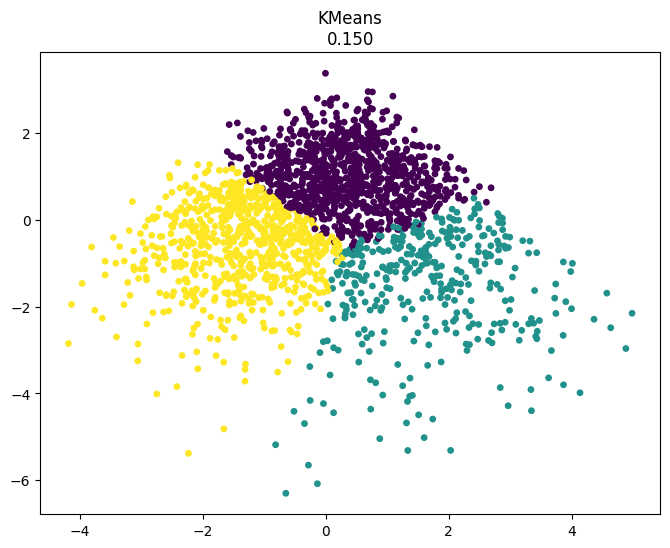

In [9]:
k = KMeans(
n_clusters=3,
n_init=10,
random_state=42
).fit_predict(
X_scaled
)

k_score = silhouette_score(
X_scaled,
k
)

plt.figure(figsize=(8,6))

plt.scatter(
X_plot[:,0],
X_plot[:,1],
c=k,
s=15
)

plt.title(
f"KMeans\n{k_score:.3f}"
)

plt.show()

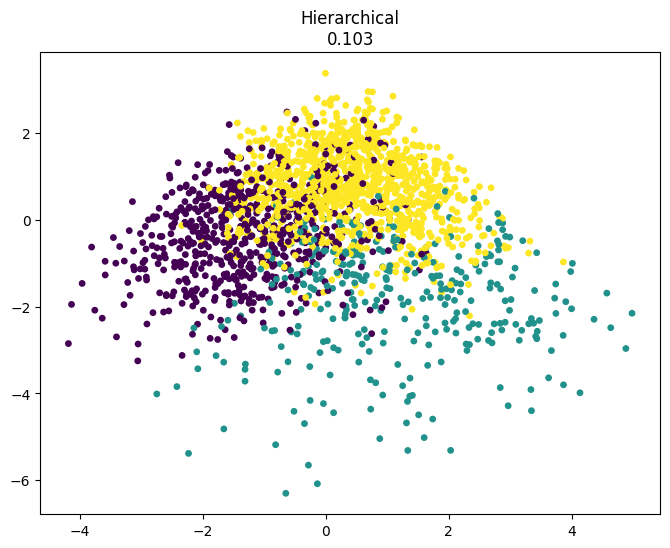

In [10]:
h = AgglomerativeClustering(
n_clusters=3
).fit_predict(
X_scaled
)

h_score = silhouette_score(
X_scaled,
h
)

plt.figure(figsize=(8,6))

plt.scatter(
X_plot[:,0],
X_plot[:,1],
c=h,
s=15
)

plt.title(
f"Hierarchical\n{h_score:.3f}"
)

plt.show()

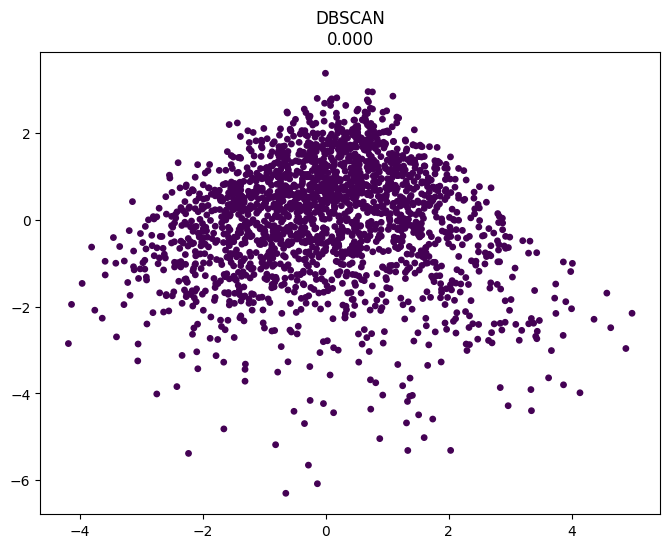

In [11]:
d = DBSCAN(
eps=1,
min_samples=8
).fit_predict(
X_scaled
)

if len(set(d)) > 1:
    d_score = silhouette_score(
        X_scaled,
        d
    )
else:
    d_score = 0

plt.figure(figsize=(8,6))

plt.scatter(
X_plot[:,0],
X_plot[:,1],
c=d,
s=15
)

plt.title(
f"DBSCAN\n{d_score:.3f}"
)

plt.show()

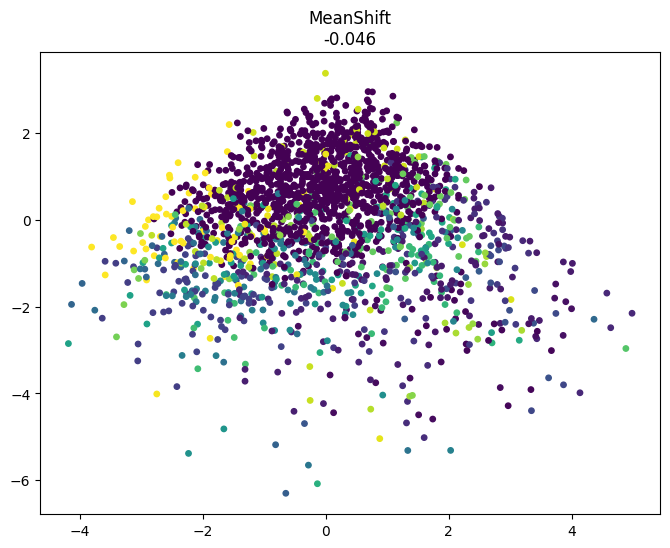

In [12]:
m = MeanShift(
bandwidth=2
).fit_predict(
X_scaled
)

m_score = silhouette_score(
X_scaled,
m
)

plt.figure(figsize=(8,6))

plt.scatter(
X_plot[:,0],
X_plot[:,1],
c=m,
s=15
)

plt.title(
f"MeanShift\n{m_score:.3f}"
)

plt.show()

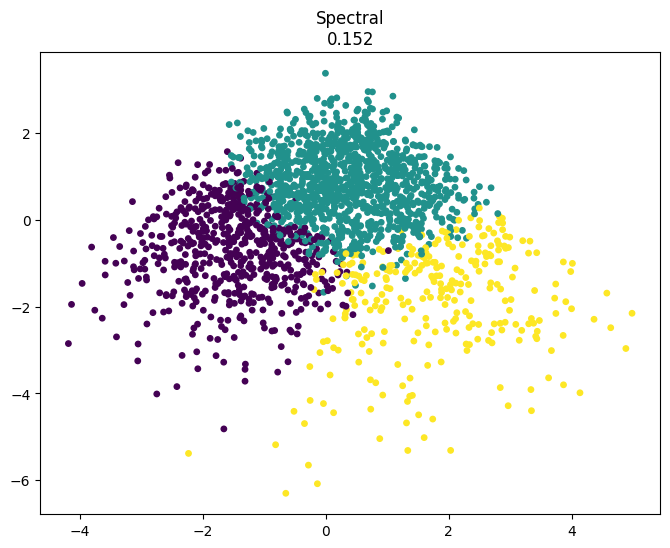

In [13]:
s = SpectralClustering(
n_clusters=3,
affinity="nearest_neighbors",
n_neighbors=10,
random_state=42
).fit_predict(
X_scaled
)

s_score = silhouette_score(
X_scaled,
s
)

plt.figure(figsize=(8,6))

plt.scatter(
X_plot[:,0],
X_plot[:,1],
c=s,
s=15
)

plt.title(
f"Spectral\n{s_score:.3f}"
)

plt.show()

In [14]:
results = pd.DataFrame({

"Algorithm":[
"KMeans",
"Hierarchical",
"DBSCAN",
"MeanShift",
"Spectral"
],

"Score":[
k_score,
h_score,
d_score,
m_score,
s_score
]

})

print(results)

best = results.loc[
results.Score.idxmax()
]

print()

print(
"BEST CLUSTERING:"
)

print(
best["Algorithm"]
)

print(
"Score:",
round(
best["Score"],
3
)
)

      Algorithm     Score
0        KMeans  0.150216
1  Hierarchical  0.103261
2        DBSCAN  0.000000
3     MeanShift -0.045777
4      Spectral  0.152117

BEST CLUSTERING:
Spectral
Score: 0.152
